In [2]:
# -*- coding: utf-8 -*-

import numpy as np
import pandas as pd
import statsmodels.api as sm
from statsmodels.discrete.discrete_model import MNLogit
from statsmodels.miscmodels.ordinal_model import OrderedModel
from statsmodels.stats.multitest import multipletests
from scipy.stats import chi2
import warnings
import os

warnings.filterwarnings('ignore')

# ============================================================================
# 0. 配置
# ============================================================================
output_dir = r"mediation_results_counterfactual"
if not os.path.exists(output_dir):
    os.makedirs(output_dir)

np.random.seed(2026)

# ============================================================================
# 1. 读入数据
# ============================================================================
df_val = pd.read_excel(r"gist_data2_4alldata2.xlsx")
df_val['Echo Uniformity'] = 1 - df_val['Echo Uniformity']
df_val['ShapeRegularity'] = 1 - df_val['ShapeRegularity']
df_val['Location'] = 1 - df_val['Location']
df_val['Boundary Clarity'] = 1 - df_val['Boundary Clarity']

continuous_vars = ['MaximumTumorSize', 'KI_67']
for var in continuous_vars:
    if var in df_val.columns:
        mean_val = df_val[var].mean()
        std_val = df_val[var].std()
        if std_val > 0:
            df_val[var] = (df_val[var] - mean_val) / std_val

# Variable definition 


Y = "RiskCategory_encoded"
X_list = ['EndoscopicUltrasoundType','Origin Layer','Echo Uniformity','Growth Pattern','Boundary Clarity',
          'MaximumTumorSize','Location','Ulceration','ShapeRegularity','BloodFlowSignal','Echo']  #
M_list = ['CD34','CD117','PDGFR-α','Dog-1','S-100','SMA','KI_67']


df_val['GrowthPattern_binary'] = df_val['Growth Pattern'].map({0:0, 1:0, 2:1})
df_val['EUS_type_binary'] = df_val['EndoscopicUltrasoundType'].map({1:0, 2:1, 3:1}) 

X_list.remove('Growth Pattern')
X_list.remove('EndoscopicUltrasoundType')
X_list.append('GrowthPattern_binary')
X_list.append('EUS_type_binary')



In [31]:

# ============================================================================
# proportional odds
# ============================================================================
def test_proportional_odds(df, X, M, Y):
    data = df[[X, M, Y]].dropna().copy()
    data[Y] = pd.Categorical(data[Y]).codes
    try:
        model_ord = OrderedModel(data[Y], data[[X, M]], distr='logit')
        res_ord = model_ord.fit(disp=False)
        ll_ord = res_ord.llf
        X_const = sm.add_constant(data[[X, M]])
        model_mn = MNLogit(data[Y], X_const)
        res_mn = model_mn.fit(disp=False)
        ll_mn = res_mn.llf
        lr = 2 * (ll_mn - ll_ord)
        df_lr = (len(data[Y].unique())-2) * 2
        p = chi2.sf(lr, df_lr)
        return p
    except:
        return np.nan

po_results = {}
for X in X_list:
    for M in M_list:
        p = test_proportional_odds(df_val, X, M, Y)
        po_results[(X, M)] = p
        print(f"{X} → {M}: p={p:.4f}")

# 将po_results转换为DataFrame
po_df = pd.DataFrame([{'X': k[0], 'M': k[1], 'p_value': v} for k, v in po_results.items()])
# 保存到指定文件夹（假设output_dir已定义）
#po_df.to_csv(os.path.join(output_dir, "proportional_odds_test_results.csv"), index=False,encoding='utf-8-sig')


Origin Layer → CD34: p=0.1397
Origin Layer → CD117: p=0.0750
Origin Layer → PDGFR-α: p=0.1010
Origin Layer → Dog-1: p=0.3396
Origin Layer → S-100: p=0.4113
Origin Layer → SMA: p=0.4890
Origin Layer → KI_67: p=0.0189
Echo Uniformity → CD34: p=0.2430
Echo Uniformity → CD117: p=0.1179
Echo Uniformity → PDGFR-α: p=0.1289
Echo Uniformity → Dog-1: p=0.5024
Echo Uniformity → S-100: p=0.5521
Echo Uniformity → SMA: p=0.5735
Echo Uniformity → KI_67: p=0.0538
Boundary Clarity → CD34: p=0.0893
Boundary Clarity → CD117: p=0.0359
Boundary Clarity → PDGFR-α: p=0.0595
Boundary Clarity → Dog-1: p=0.2092
Boundary Clarity → S-100: p=0.2725
Boundary Clarity → SMA: p=0.3725
Boundary Clarity → KI_67: p=0.0405
MaximumTumorSize → CD34: p=0.0000
MaximumTumorSize → CD117: p=0.0000
MaximumTumorSize → PDGFR-α: p=0.0000
MaximumTumorSize → Dog-1: p=0.0000
MaximumTumorSize → S-100: p=0.0000
MaximumTumorSize → SMA: p=0.0000
MaximumTumorSize → KI_67: p=0.0000
Location → CD34: p=0.0424
Location → CD117: p=0.0202
Locati

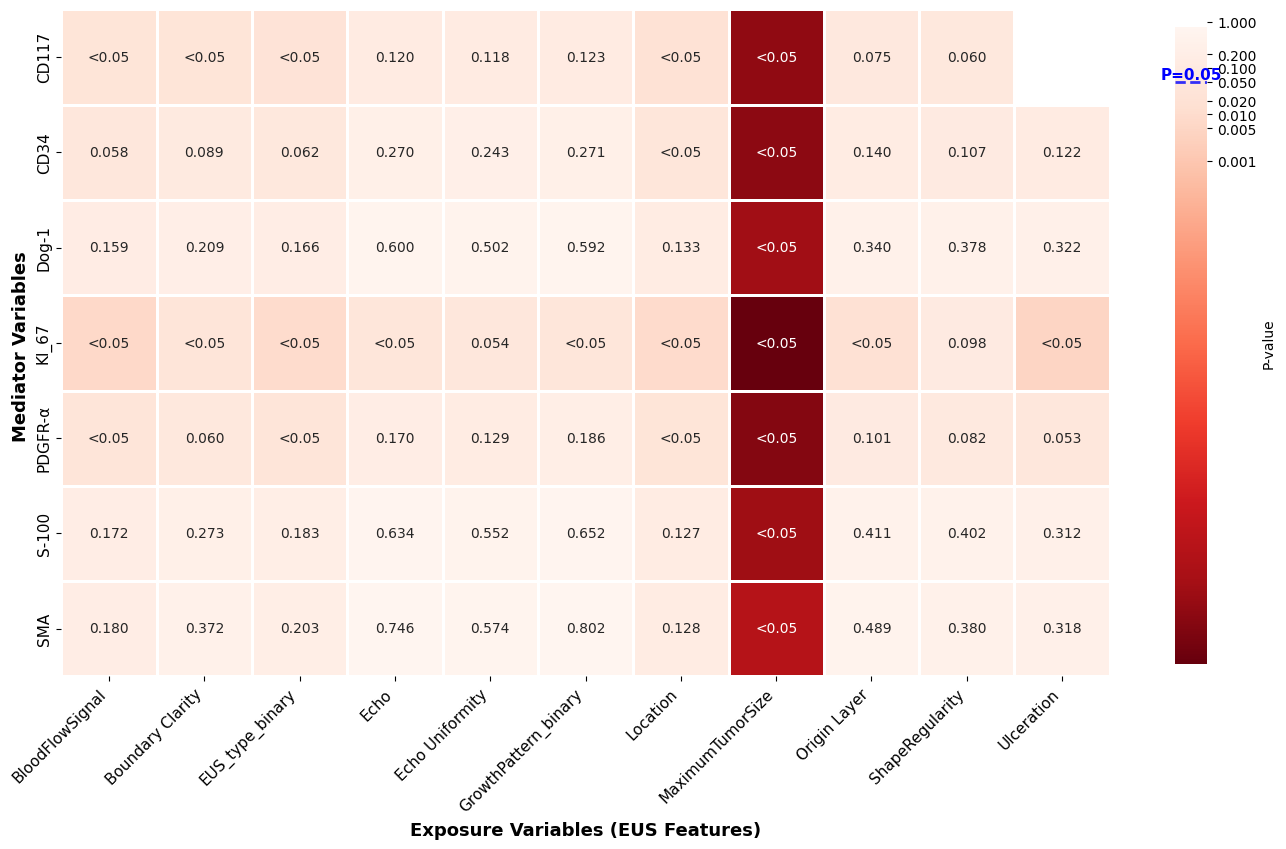

热力图已保存至: mediation_results_counterfactual\heatmap_proportional_odds.png

显著配对 (P < 0.05): 23/77 (29.9%)


In [35]:
# -*- coding: utf-8 -*-

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# ============================================================================
# 绘制热力图：X-M关联的P值
# ============================================================================

# 1. 从po_df创建矩阵（M为纵轴，X为横轴）
pivot_p = po_df.pivot(index='M', columns='X', values='p_value')

# 2. 计算 -log10(P) 矩阵：值越大越显著
pivot_log = -np.log10(pivot_p)

# 3. 创建注释矩阵
def format_p_value(p):
    if p < 0.05:
        return '<0.05'
    else:
        return f'{p:.3f}'

annot_matrix = pivot_p.applymap(lambda x: format_p_value(x))

# ============================================================================
# 绘制热力图
# ============================================================================
fig, ax = plt.subplots(figsize=(14, 10))

heatmap = sns.heatmap(pivot_log,
                      annot=annot_matrix,
                      fmt='',
                      cmap='Reds',
                      cbar_kws={'label': 'P-value','shrink': 0.7},
                      linewidths=1,
                      linecolor='white',
                      square=True,
                      ax=ax)

# ========== 修改Colorbar显示P值 ==========
cbar = heatmap.collections[0].colorbar

# 定义要在colorbar上显示的位置（-log10(P)值）
# 注意：位置从小到大排列（下面小，上面大）
log_positions = [0, 0.301, 0.523, 0.699, 0.823, 1.000, 1.301, 1.523, 1.699, 2.000, 2.301, 3.000]
p_labels = ['1.000', '0.500', '0.300', '0.200', '0.150', '0.100', '0.050', '0.030', '0.020', '0.010', '0.005', '0.001']

# 只保留部分刻度避免太密集（从下到上：P值从大到小）
selected_positions = [0, 0.699, 1.000, 1.301, 1.699, 2.000, 2.301, 3.000]
selected_labels = ['1.000', '0.200', '0.100', '0.050', '0.020', '0.010', '0.005', '0.001']

cbar.set_ticks(selected_positions)
cbar.set_ticklabels(selected_labels)
#cbar.set_ticks([0] + selected_positions)
#cbar.set_ticklabels(['0.000'] + selected_labels)

# 添加P=0.05的参考线
threshold = -np.log10(0.05)  # ≈ 1.301
cbar.ax.axhline(y=threshold, color='blue', linestyle='--', linewidth=2, alpha=0.8)
cbar.ax.text(0.5, threshold, 'P=0.05', transform=cbar.ax.transData, 
             color='blue', fontsize=11, ha='center', va='bottom', fontweight='bold')

# 修改Colorbar方向：让数值小的在下面，数值大的在上面
# 注意：默认情况下，heatmap的cbar是下面数值小，上面数值大
# 但我们的刻度设置已经是这个方向了，所以不需要额外翻转

# 如果你发现Colorbar是反的，可以用以下方法翻转
cbar.ax.invert_yaxis()  # 取消注释这行可以翻转

# 美化
ax.set_xlabel('Exposure Variables (EUS Features)', fontsize=13, fontweight='bold')
ax.set_ylabel('Mediator Variables ', fontsize=13, fontweight='bold')
#ax.set_title('Association between Immunohistochemical Markers and EUS Features\n(Proportional Odds Test P-values)', fontsize=15, fontweight='bold', pad=20)

plt.xticks(rotation=45, ha='right', fontsize=11)
plt.yticks(fontsize=11)

plt.tight_layout()
plt.savefig(os.path.join(output_dir, "heatmap_proportional_odds.png"), dpi=300, bbox_inches='tight')
plt.show()
print(f"热力图已保存至: {os.path.join(output_dir, 'heatmap_proportional_odds.png')}")

# ============================================================================
# 输出统计信息
# ============================================================================
sig_count = (pivot_p < 0.05).sum().sum()
total_count = pivot_p.size
print(f"\n显著配对 (P < 0.05): {sig_count}/{total_count} ({sig_count/total_count*100:.1f}%)")